In [30]:
from langdetect import detect
import pandas as pd
from tqdm import tqdm

def is_spanish(text):
    try:
        return detect(text) == 'es'
    except: #en caso de error o idioma no detectado
        return False

def filter_reseñas_esp(filename):
    df = pd.read_csv(filename)
    count_original = df.shape[0]
    
    filtered_df = df[df["body"].apply(is_spanish)]
    filtered_df.to_csv(filename, index = False, encoding = "utf-8")
    count_final = filtered_df.shape[0]

    diff = count_original - count_final 
    return (filtered_df, diff)

if __name__ == "__main__":
    base_df = pd.read_csv('new_database/base.csv')

    dataframes = []

    for ID in base_df['ID']:
        id_df = pd.read_csv(f'new_database/{ID}.csv')
        category = base_df.loc[base_df['ID'] == ID, 'category'].values

        reviews_df = pd.DataFrame()

        for local_id in tqdm(id_df['ID'], desc=f"Processing local_IDs for {ID}.csv"):
            review_filename = f'new_database/reviews/{local_id}.csv'
        
            (filtered_df, count) = filter_reseñas_esp(review_filename)
            #print(f'Deleted {count} reviews in {review_filename}')

            reviews_df = pd.concat([reviews_df, filtered_df], ignore_index=True)
        
        print('-'*50 + f'\nReviews left in the {category[0]} category: {reviews_df.shape[0]}')
        dataframes.append(reviews_df)

Processing local_IDs for 0.csv: 100%|█████████| 279/279 [04:38<00:00,  1.00it/s]


--------------------------------------------------
Reviews left in the Cafeteras de goteo category: 20482


Processing local_IDs for 1.csv: 100%|███████████| 98/98 [02:39<00:00,  1.63s/it]


--------------------------------------------------
Reviews left in the Cafeteras automaticas category: 16064


Processing local_IDs for 2.csv: 100%|█████████| 148/148 [03:16<00:00,  1.33s/it]

--------------------------------------------------
Reviews left in the Cafeteras individuales category: 19078


In [41]:
for i in range(len(dataframes)):
    dataframes[i].to_csv(f'category_{i}.csv', index = False, encoding = "utf-8")

<b style="font-size: 20px;">Now THAT doesn't look too good O_O</b>

In [40]:
import os

base_df = pd.read_csv('new_database/base.csv')
all_reviews = pd.DataFrame()
c = 0 # number of goods

for ID in base_df['ID']:
    id_df = pd.read_csv(f'new_database/{ID}.csv')
    category = base_df.loc[base_df['ID'] == ID, 'category'].values
    
    reviews_df = pd.DataFrame()
    
    for local_id in id_df['ID']:
        review_file = f'new_database/reviews/{local_id}.csv'
        c+=1
        
        if os.path.exists(review_file):
            review_df = pd.read_csv(review_file)
            reviews_df = pd.concat([reviews_df, review_df], ignore_index=True)
    
    print(f'Located {len(reviews_df)} reviews in {category[0]} category.')

    all_reviews = pd.concat([all_reviews, reviews_df], ignore_index=True)

print('-'*50 + f'\nTotal number of reviews in the new_database: {len(all_reviews)}\n' + '-'*50)

all_reviews.head()

Located 20483 reviews in Cafeteras de goteo category.
Located 16077 reviews in Cafeteras automaticas category.
Located 19087 reviews in Cafeteras individuales category.
--------------------------------------------------
Total number of reviews in the new_database: 55647
--------------------------------------------------


,title,rating,body,author,date
0,Regalo,"5,0 de 5 estrellas",Me gustó mucho,Cliente Amazon,Revisado en España el 6 de abril de 2024
1,No ha durado ni la garantía + pésimo servicio ...,"1,0 de 5 estrellas","Ni los 24 meses de garantía ha durado, y al en...",MaX,Revisado en España el 3 de abril de 2024
2,Está bien,"3,0 de 5 estrellas",Después de más de dos meses usándola hace muy ...,Lorena,Revisado en España el 14 de marzo de 2024
3,Perfecta!,"5,0 de 5 estrellas",Me encanta! Soy adicta al café y me gusta toma...,Perfecta!,Revisado en España el 22 de febrero de 2024
4,EXCELENTE,"5,0 de 5 estrellas",como única pega que limpiar el palito del vapo...,Sil at,Revisado en España el 20 de febrero de 2024


----
<p style="text-align: center; font-size: 25px; margin-top: 20px;">
    <strong>
          Polarity analysis 
    </strong>
</p>

---

In [46]:
import spacy
from textblob import TextBlob
from tqdm import tqdm

nlp = spacy.load('en_core_web_sm')

def analyze_sentiment(review):

    doc = nlp(review) # tokenizer 
    
    processed_review = " ".join([token.text for token in doc]) # adjusting for TextBlob

    blob = TextBlob(processed_review)
    
    polarity = blob.sentiment.polarity # getting polarity between -1.0 and 1.0
    return polarity

if __name__ == "__main__":

    polarities = []
    for i in range(3):
        df = pd.read_csv(f'new_database/category_{i}.csv')

        neg = 0
        neu = 0
        pos = 0
        for body in tqdm(df['body'], desc = f"Processing reviews in category_{i}.csv"):
            polarity = analyze_sentiment(body)
            if polarity > 0:
                pos += 1
                continue 
            if polarity < 0:
                neg += 1
                continue
            else:
                neu += 1
                
        polarities.append((pos, neu, neg))

Processing reviews in category_0.csv: 100%|█| 20194/20194 [02:38<00:00, 127.04it
Processing reviews in category_1.csv: 100%|█| 15933/15933 [02:51<00:00, 92.66it/
Processing reviews in category_2.csv: 100%|█| 18644/18644 [02:15<00:00, 137.65it


In [47]:
polarities

[(1837, 17704, 653), (2282, 13275, 376), (1618, 16688, 338)]

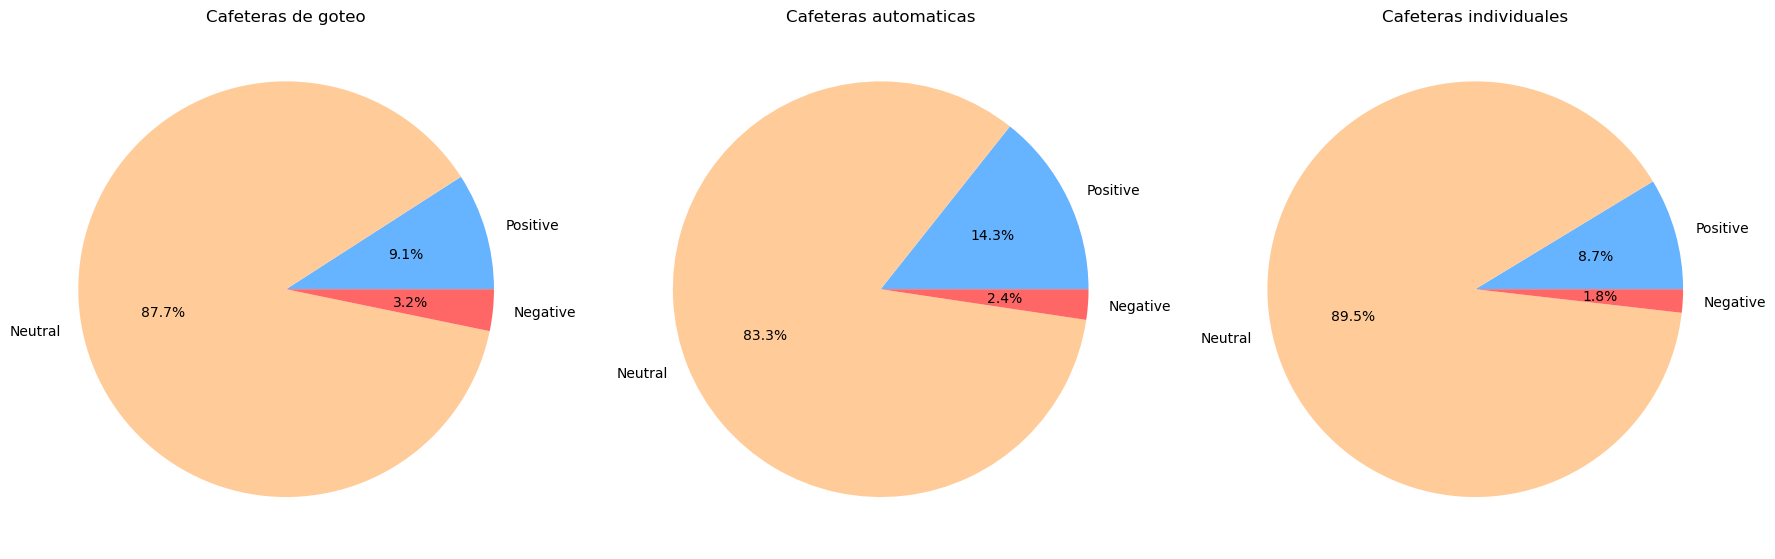

In [48]:
import matplotlib.pyplot as plt

base = pd.read_csv("new_database/base.csv") # naming categories
categories = []

for i in base["category"]:
    categories.append(i)

labels = ['Positive', 'Neutral', 'Negative']


fig, axis = plt.subplots(1, 3, figsize=(18, 6)) # creating a shape and an axis

for i, (ax, data) in enumerate(zip(axis, polarities)):
    ax.pie(data, labels=labels, autopct='%1.1f%%', colors=['#66b3ff','#ffcc99','#ff6666'])
    ax.set_title(categories[i])

plt.tight_layout() #showing diagrams
plt.show()


----
<p style="text-align: center; font-size: 25px; margin-top: 20px;">
    <strong>
          Topic modelling with Latent Dirichlet Allocation (LDA)
    </strong>
</p>

---